<div style="background-color: #1A3A5C; padding: 30px; border-radius: 10px; text-align: center;">
  <h1 style="color: white; font-size: 2em; margin-bottom: 8px;">
     Laboratório — Transformada Discreta de Fourier
  </h1>
  <h2 style="color: #AED6F1; font-weight: normal; margin-bottom: 6px;">
    DFT · IDFT · Time Aliasing · Zero-Padding
  </h2>
  <h3 style="color: #AED6F1; font-weight: normal; margin-bottom: 4px;">
    Disciplina: Processamento Digital de Sinais
  </h3>
  <h3 style="color: #AED6F1; font-weight: normal;">
    Professora: Luciana Ribeiro Veloso — UFCG / DEE
  </h3>
</div>

---

## Sobre este laboratório

Notebook autocontido — todos os experimentos rodam diretamente aqui,
sem dependência de arquivos externos.

| Seção | Conteúdo |
|---|---|
| **1** | Motivação — da TFTD à DFT: o problema da representação computacional |
| **2** | Amostragem no domínio da frequência — como a DFT amostra a TFTD |
| **3** | DFT — definição, par análise/síntese e cálculo manual |
| **4** | IDFT — reconstrução do sinal e extensão periódica $x_p(n)$ |
| **5** | Time Aliasing — condição $L \leq N$ e consequências da violação |
| **6** | Zero-Padding — efeito espectral da inserção de zeros |
| **7** | Exemplo resolvido — pulso retangular: DFT com N=L e N>L |
| **8** | Série, Transformada e DFT — panorama unificado |
| **9** | Roteiro de sala |
| **10** | Questões para Reflexão |

> **Pré-requisito:** Série de Fourier de Tempo Discreto (SFTD), Transformada de Fourier de Tempo Discreto (TFTD), sinais de duração finita.

---

##  Configuração — execute esta célula antes de qualquer experimento

Esta célula importa todas as bibliotecas utilizadas no laboratório e
configura o estilo visual padrão dos gráficos. **Execute-a uma única vez ao abrir o notebook.**

In [1]:
# ── Bibliotecas científicas ───────────────────────────────────────
import numpy as np

# ── Visualização ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Interatividade ────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Estilo visual padrão dos gráficos ─────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.color'       : '#dee2e6',
    'grid.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
})

# ── Paleta de cores padrão do laboratório ─────────────────────────
C_ORIG  = '#1A5FA8'   # azul   — sinal / TFTD original
C_DSEM  = '#C0392B'   # verm.  — time aliasing / violação L>N
C_DCOM  = '#117A65'   # verde  — sinal correto / L≤N
C_DFT   = '#8E44AD'   # roxo   — amostras DFT / bins
C_ZEROS = '#E67E22'   # laran. — zeros inseridos / zero-padding
C_PER   = '#C0392B'   # verm.  — extensão periódica xp[n]
C_CINZA = '#5D6D7E'   # cinza  — referência

def stem_plot(ax, n, x, color, label='', marksize=7):
    """Plota um sinal discreto no estilo stem com estética padronizada."""
    ax.axhline(0, color='#495057', linewidth=0.8, zorder=1)
    for ni, xi in zip(n, x):
        ax.plot([ni, ni], [0, xi], color=color, lw=1.8, zorder=2)
    ax.plot(n, x, 'o', markersize=marksize, color=color,
            markeredgecolor='white', markeredgewidth=1.1, zorder=3, label=label)

print('Configuração concluída — pode executar as seções a seguir.')

Configuração concluída — pode executar as seções a seguir.


---

## <span style="color: #1A5FA8;">1. Motivação — Da TFTD à DFT</span>

### O problema da representação computacional

A **Transformada de Fourier de Tempo Discreto (TFTD)** de um sinal $x(n)$ é:

$$X(e^{j\omega}) = \sum_{n=-\infty}^{+\infty} x(n)\, e^{-j\omega n}$$

Essa transformada um problema para implementação computacional:

* $X(e^{j\omega})$ é uma função contínua e períodica em $\omega$, impossível de armazenar ou calcular em um computador digital.

**Solução:** amostrar $X(e^{j\omega})$ em $N$ pontos igualmente espaçados em $[0, 2\pi)$:

$$\omega_k = \frac{2\pi k}{N}, \qquad k = 0, 1, \ldots, N-1$$

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 12px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #1A5FA8;">Ideia central:</strong><br>
A TFTD é periódica em $\omega$ com período $2\pi$. Portanto, basta amostrar
<strong>um único período</strong> $[0, 2\pi)$ em $N$ pontos para representá-la completamente —
desde que o sinal $x(n)$ tenha duração finita $L \leq N$.
O resultado é a <strong>Transformada Discreta de Fourier (DFT)</strong>.
</div>

### Etapa 1 — Visualizando a TFTD de um sinal de duração finita

In [2]:
# ── Sinal de duração finita: pulso retangular de comprimento L ────
L = 5          # duração do sinal (número de amostras não nulas)
n_sig = np.arange(L)
x     = np.ones(L)   # x(n) = 1 para 0 ≤ n ≤ L-1

# ── TFTD avaliada em 1024 pontos — dois períodos [0, 4π) ─────────
N_cont = 1024
omega  = np.linspace(0, 4 * np.pi, N_cont, endpoint=False)
X_cont = np.array([np.sum(x * np.exp(-1j * w * n_sig)) for w in omega])

# TFTD em [0, 2π) — usada nos gráficos da DFT
omega_1per = np.linspace(0, 2 * np.pi, N_cont // 2, endpoint=False)
X_1per     = np.array([np.sum(x * np.exp(-1j * w * n_sig)) for w in omega_1per])

# ── Slider: usuário escolhe N_dft ────────────────────────────────
slider_N = widgets.IntSlider(
    value=8, min=L, max=32, step=1,
    description='N (pontos DFT):',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)
saida = widgets.Output()

def plotar(change):
    N_dft = change['new']
    k       = np.arange(N_dft)
    omega_k = 2 * np.pi * k / N_dft
    X_dft   = np.array([np.sum(x * np.exp(-1j * (2*np.pi*ki/N_dft) * n_sig)) for ki in k])

    with saida:
        saida.clear_output(wait=True)

        fig = plt.figure(figsize=(14, 9))
        gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

        # Sinal x(n)
        ax0 = fig.add_subplot(gs[0, 0])
        n_ext = np.arange(-2, L + 3)
        x_ext = np.array([1.0 if 0 <= ni < L else 0.0 for ni in n_ext])
        stem_plot(ax0, n_ext, x_ext, C_ORIG)
        ax0.set_title(f'Sinal $x(n)$ — pulso retangular (L={L})')
        ax0.set_xlabel('n'); ax0.set_ylabel('x(n)')
        ax0.set_ylim([-0.3, 1.5])

        # |TFTD| — dois períodos [0, 4π)
        ax1 = fig.add_subplot(gs[0, 1])
        ax1.plot(omega / np.pi, np.abs(X_cont), color=C_ORIG, lw=1.8,
                 label='$|X(e^{j\\omega})|$ — TFTD (contínua)')
        ax1.axvspan(2, 4, alpha=0.06, color=C_DFT, label='2º período (repetição)')
        ax1.set_title('TFTD — magnitude em dois períodos $[0,\\, 4\\pi)$')
        ax1.set_xlabel('$\\omega $'); ax1.set_ylabel('$|X(e^{j\\omega})|$')
        ax1.set_xlim([0, 4])
        ax1.set_xticks([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4])
        ax1.set_xticklabels(['0','π/2','π','3π/2','2π','5π/2','3π','7π/2','4π'], fontsize=8)
        ax1.legend(fontsize=8)

        # |X(k)| — DFT
        ax2 = fig.add_subplot(gs[1, 0])
        ax2.plot(omega_1per / np.pi, np.abs(X_1per), color=C_ORIG, lw=1.5, alpha=0.4, label='TFTD')
        stem_plot(ax2, omega_k / np.pi, np.abs(X_dft), C_DFT, label=f'DFT  N={N_dft}')
        ax2.set_title(f'DFT de N={N_dft} pontos — amostrando a TFTD')
        ax2.set_xlabel('$\\omega$ = $2\\pi k / N$'); ax2.set_ylabel('$|X(k)|$')
        ax2.legend(fontsize=9)

        # Fase X(k)
        ax3 = fig.add_subplot(gs[1, 1])
        ax3.plot(omega_1per / np.pi, np.angle(X_1per), color=C_ORIG, lw=1.5, alpha=0.4, label='TFTD (fase)')
        stem_plot(ax3, omega_k / np.pi, np.angle(X_dft), C_DFT, label=f'DFT (fase) N={N_dft}')
        ax3.set_title('DFT — fase')
        ax3.set_xlabel('$\\omega / \\pi$'); ax3.set_ylabel('$\\angle X(k)$ (rad)')
        ax3.legend(fontsize=9)

        plt.suptitle(f'Da TFTD (contínua) à DFT (amostras): N={N_dft} pontos  |  Δω = 2π/{N_dft} = {2*np.pi/N_dft:.3f} rad',
                     fontsize=12, fontweight='bold')
      
        plt.show()


slider_N.observe(plotar, names='value')
display(slider_N, saida)
plotar({'new': slider_N.value})

IntSlider(value=8, continuous_update=False, description='N (pontos DFT):', layout=Layout(width='500px'), max=3…

Output()

### 💡 O que observar

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">DFT como amostras da TFTD</strong><br>
Os círculos roxos (DFT) caem exatamente sobre a curva contínua azul (TFTD).
A DFT não é uma aproximação. É exatamente a TFTD avaliada nos $N$ pontos $\omega_k = 2\pi k/N$.
A informação entre esses pontos é perdida na representação digital.
</div>

<div style="background-color: #FEF9E7; border-left: 4px solid #E67E22; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #E67E22;">Para registrar</strong><br>
Altere $N_{dft}$ para 5, 10 e 20 e reexecute. Com N maior, há mais amostras da TFTD.
Com $N < L$, o que acontece com a reconstrução? Isso é estudado na Seção 5 (Time Aliasing).
</div>

---

## <span style="color: #1A5FA8;">2. Amostragem no Domínio da Frequência</span>

### Como a DFT amostra a TFTD

Considere $x(n)$ com duração finita $L$ (ou seja, $x(n) = 0$ para $n < 0$ e $n \geq L$).
A TFTD é:

$$X(e^{j\omega}) = \sum_{n=0}^{L-1} x(n)\, e^{-j\omega n}$$

Amostrando em $\omega_k = \dfrac{2\pi k}{N}$, para $k = 0, 1, \ldots, N-1$:

$$X(k) = X(e^{j\omega})\bigg|_{\omega = 2\pi k/N} = \sum_{n=0}^{N-1} x(n\, e^{-j\frac{2\pi}{N}kn}$$

onde $N \geq L$ (o sinal é completado com zeros se $L < N$).

### Mapeamento dos bins de frequência

Cada bin $k$ corresponde a uma frequência física:

$$f_k = k \cdot \frac{F_s}{N} \quad [\text{Hz}] \qquad \Longleftrightarrow \qquad \omega_k = \frac{2\pi k}{N} \quad [\text{rad/amostra}]$$

Lembre-se que $F_s$ é a frequência de amostragem usado para obter a representação discreta do sinal $x(n)$ através do processo de amostragem do sinal contíuo no tempo $x(t)$

| Bin $k$ | $\omega_k$ | Frequência física ($F_s = 8000$ Hz, $N=8$) |
|:---:|:---:|:---:|
| 0 | 0 | 0 Hz (DC) |
| 1 | $\pi/4$ | 1000 Hz |
| 2 | $\pi/2$ | 2000 Hz |
| 4 | $\pi$ | 4000 Hz (Nyquist) |
| 5 | $5\pi/4$ | −3000 Hz (frequ. negativa) |
| 7 | $7\pi/4$ | −1000 Hz |

---

## <span style="color: #1A5FA8;">3. DFT — Definição da Transformada Discreta de Fourier - DFT (Discrete Fourier Transformers)</span>

### Definição formal

Se $x(n)$ é um sinal de tempo discreto, causal, de comprimento $L$, e $N \geq L$:

$$\boxed{X(k) = \sum_{n=0}^{N-1} x(n)\, e^{-j\frac{2\pi}{N}kn}, \quad k = 0, 1, \ldots, N-1}$$




### Etapa 1 — Cálculo manual da DFT (implementação direta da fórmula)

In [3]:
def dft_direta(x, N):
    """
    DFT de N pontos calculada diretamente pela definição:
        X(k) = Σ x(n) * W_N^{kn},  k = 0,...,N-1
    O sinal x é completado com zeros se len(x) < N.
    """
    L = len(x)
    # zero-padding se necessário
    x_pad = np.concatenate([x, np.zeros(N - L)]) if N > L else np.array(x[:N], dtype=complex)
    X = np.zeros(N, dtype=complex)
    W_N = np.exp(-1j * 2 * np.pi / N)          
    for k in range(N):
        for n in range(N):
            X[k] += x_pad[n] * W_N**(k * n)    # X(k) = Σ x(n) W_N^{kn}
    return X

# ── Exemplo: pulso retangular L=4, N=4 ───────────────────────────
L = 4
N = 4
x = np.ones(L)

print('=' * 60)
print(f'Sinal: x(n) = 1 para 0 ≤ n ≤ {L-1}  |  N = {N}')
print('=' * 60)

W_N = np.exp(-1j * 2 * np.pi / N)


X_manual = dft_direta(x, N)
X_numpy  = np.fft.fft(x, n=N)

print(f'{"k":>3} | {"X(k) manual":>30} | {"|X(k)|":>8} | {"ang X(k) (graus)":>18}')
print('-' * 60)
for k_i, Xk in enumerate(X_manual):
    print(f'{k_i:>3} | {str(np.round(Xk, 4)):>30} | {abs(Xk):>8.4f} | {np.angle(Xk)*180/np.pi:>10.2f}')

print()
print(f'Verificação vs numpy: erro máximo = {np.max(np.abs(X_manual - X_numpy)):.2e}')

Sinal: x(n) = 1 para 0 ≤ n ≤ 3  |  N = 4
  k |                    X(k) manual |   |X(k)| |   ang X(k) (graus)
------------------------------------------------------------
  0 |                         (4+0j) |   4.0000 |       0.00
  1 |                        (-0-0j) |   0.0000 |    -129.60
  2 |                            -0j |   0.0000 |     -90.00
  3 |                            -0j |   0.0000 |     -45.35

Verificação vs numpy: erro máximo = 4.68e-16


### Etapa 2 — Visualização do espectro DFT

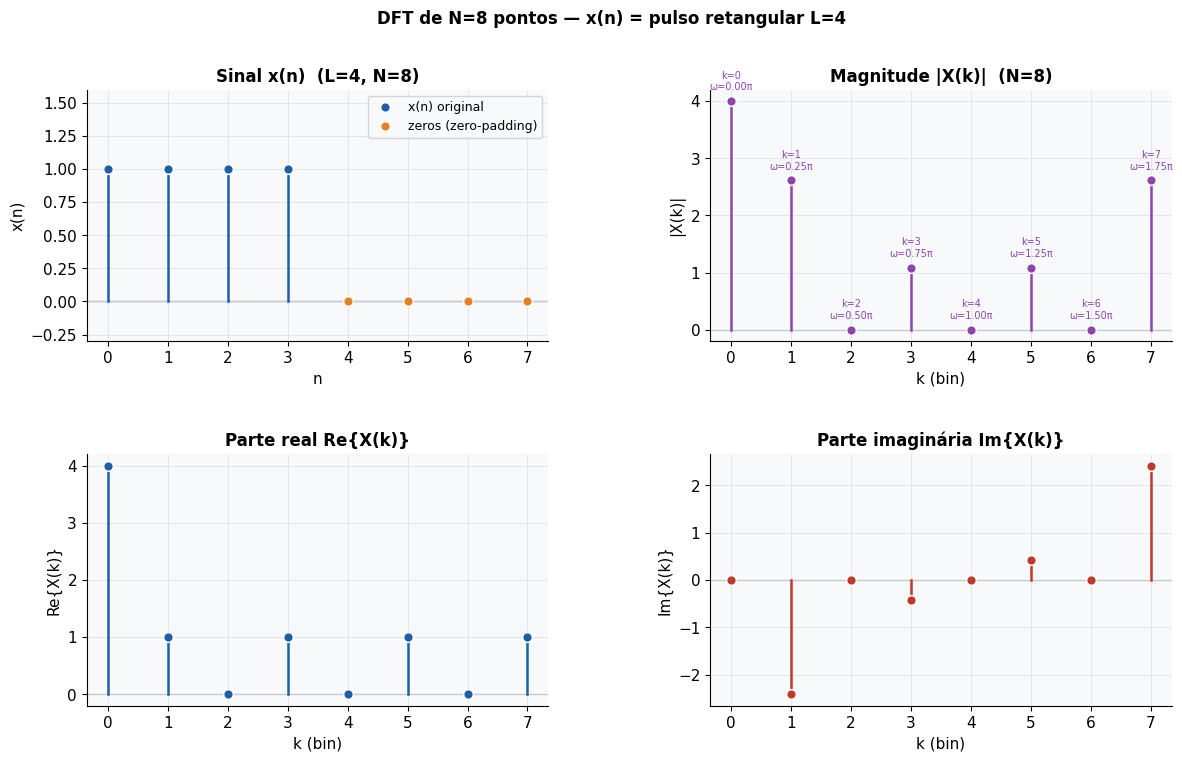

x(n) = [1. 1. 1. 1. 0. 0. 0. 0.]
X(k) = [ 4.+0.j     1.-2.414j -0.-0.j     1.-0.414j  0.-0.j     1.+0.414j
  0.-0.j     1.+2.414j]


In [4]:
# ── Parâmetros ───────────────────────────────────────────────────
L = 4
N = 8      # experimente N = L (4) e N > L (8, 16)
x = np.ones(L)

X = dft_direta(x, N)
k = np.arange(N)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# Sinal x(n) (com zero-padding visível)
n_show = np.arange(N)
x_show = np.concatenate([x, np.zeros(N - L)])
stem_plot(axes[0,0], np.arange(L),        x[:L],          C_ORIG,  label='x(n) original')
if N > L:
    stem_plot(axes[0,0], np.arange(L, N), np.zeros(N - L), C_ZEROS, label='zeros (zero-padding)')
axes[0,0].set_title(f'Sinal x(n)  (L={L}, N={N})')
axes[0,0].set_xlabel('n'); axes[0,0].set_ylabel('x(n)')
axes[0,0].legend(fontsize=9)
axes[0,0].set_ylim([-0.3, 1.6])

# |X(k)| — magnitude
stem_plot(axes[0,1], k, np.abs(X), C_DFT)
axes[0,1].set_title(f'Magnitude |X(k)|  (N={N})')
axes[0,1].set_xlabel('k (bin)'); axes[0,1].set_ylabel('|X(k)|')
for ki in k:
    axes[0,1].annotate(f'k={ki}\nω={2*ki/N:.2f}π',
                       (ki, np.abs(X[ki])), textcoords='offset points',
                       xytext=(0, 8), ha='center', fontsize=7, color=C_DFT)

# Re{X(k)}
stem_plot(axes[1,0], k, X.real, C_ORIG)
axes[1,0].set_title('Parte real Re{X(k)}')
axes[1,0].set_xlabel('k (bin)'); axes[1,0].set_ylabel('Re{X(k)}')

# Im{X(k)}
stem_plot(axes[1,1], k, X.imag, C_DSEM)
axes[1,1].set_title('Parte imaginária Im{X(k)}')
axes[1,1].set_xlabel('k (bin)'); axes[1,1].set_ylabel('Im{X(k)}')

plt.suptitle(f'DFT de N={N} pontos — x(n) = pulso retangular L={L}',
             fontsize=12, fontweight='bold')
plt.show()

print(f'x(n) = {x_show}')
print(f'X(k) = {np.round(X, 3)}')

### 💡 O que observar

<div style="background-color: #FEF9E7; border-left: 4px solid #E67E22; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #E67E22;">Simetria conjugada</strong><br>
Para sinais reais, $X[N-k] = X^*[k]$. Observe nos gráficos que
$|X[1]| = |X[N-1]|$ e $|X[2]| = |X[N-2]|$, etc.
Por isso, basta armazenar $N/2 + 1$ coeficientes independentes.
</div>

---

## <span style="color: #1A5FA8;">4. IDFT — Reconstrução do Sinal e Extensão Periódica</span>

### Como encontrar a IDFT

Dado que $X(k)$ são $N$ amostras igualmente espaçadas da TFTD de $x(n)$,
definimos o **sinal periódico** $x_p(n)$ como a repetição de $x(n)$ a cada $N$ amostras:

$$x_p(n) = \sum_{\ell=-\infty}^{+\infty} x(n - \ell N)$$

Como $x_p(n)$ é periódico com período $N$, podemos descrevê-lo pela **Série de Fourier**:

$$x_p(n) = \sum_{k=0}^{N-1} a_k\, e^{j\frac{2\pi}{N}kn}, \qquad a_k = \frac{1}{N}\sum_{n=0}^{N-1} x_p(n)\, e^{-j\frac{2\pi}{N}kn}$$

Identificando $a_k = X(k)/N$, obtemos:

$$\boxed{x(n) = \frac{1}{N} \sum_{k=0}^{N-1} X(k)\, e^{+j\frac{2\pi}{N}kn}, \quad 0 \leq n \leq N-1}$$

<div style="background-color: #FEF9E7; border-left: 4px solid #E67E22; padding: 12px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #E67E22;">Atenção:</strong> a IDFT recupera $x(n)$ para $0 \leq n \leq N-1$.
Se $L \leq N$, as primeiras $L$ amostras correspondem ao sinal original e as demais são zero (zero-padding).
Se $L > N$, ocorre time aliasing e a recuperação exata é impossível.
</div>

### Etapa 1 — Extensão periódica $x_p(n)$ e reconstrução via IDFT

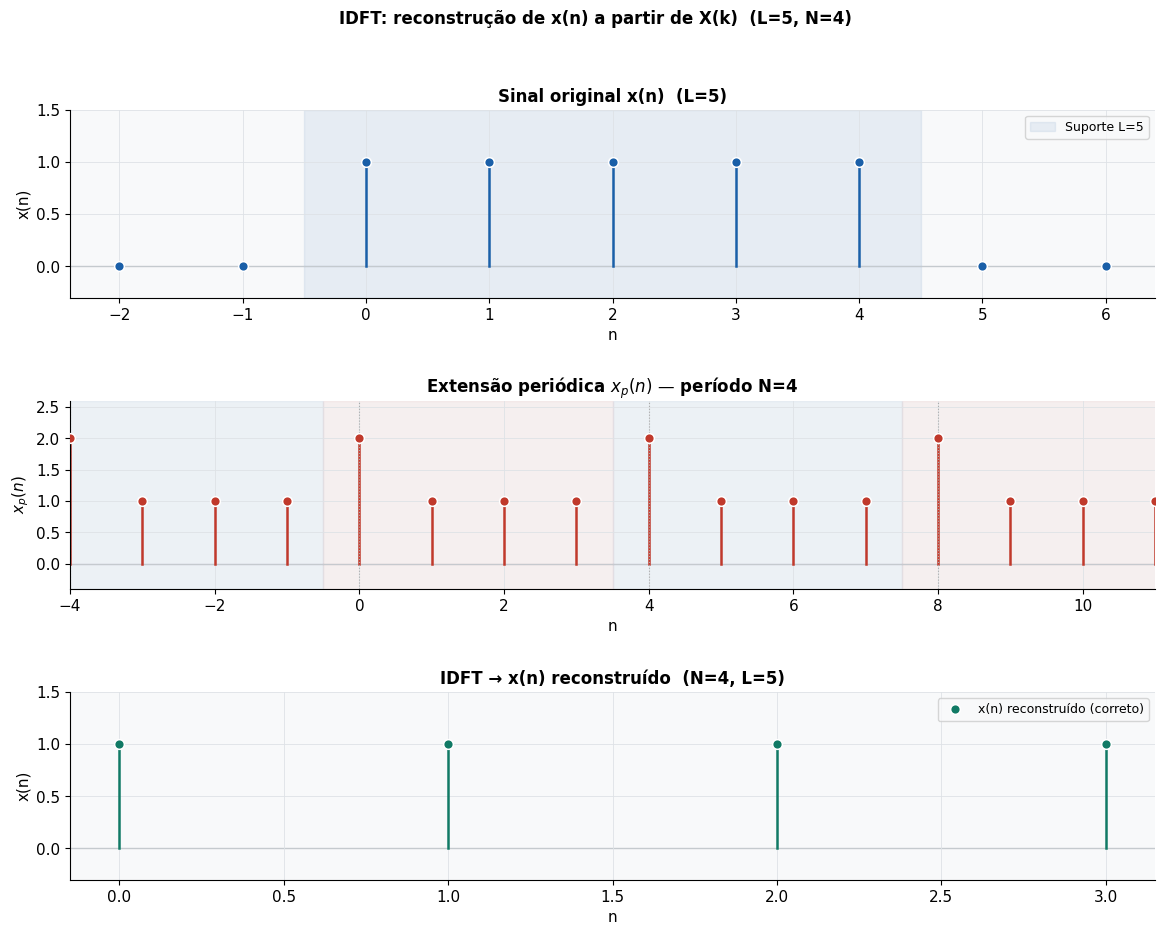

Erro máximo de reconstrução (primeiras 4 amostras): 1.11e-16
Reconstrução   COM ERRO (time aliasing —> N < L) : L=5, N=4


In [13]:
def idft_direta(X):
    """
    IDFT calculada diretamente pela definição:
        x(n) = (1/N) Σ X(k) * W_N^{-kn},  n = 0,...,N-1
    """
    N = len(X)
    x = np.zeros(N, dtype=complex)
    W_N = np.exp(-1j * 2 * np.pi / N)
    for n_i in range(N):
        for k_i in range(N):
            x[n_i] += X[k_i] * W_N**(-k_i * n_i)   # conjugado de W_N^{kn}
    return x / N

# ── Sinal original: pulso L=5 ─────────────────────────────────────
L = 5
N = 4   # N ≥ L
x_orig = np.ones(L)

# DFT
X = dft_direta(x_orig, N)

# IDFT
x_rec = idft_direta(X)

# Extensão periódica xp[n] para visualização
#n_per  = np.arange(-N, 3 * N)
#x_per  = np.array([x_orig[ni % N] if 0 <= (ni % N) < L else 0.0 for ni in n_per])
x_per = np.zeros(len(n_per))
for i, ni in enumerate(n_per):
    # soma todas as contribuições de x_orig deslocadas de múltiplos de N
    for ell in range(-3, 4):
        idx = ni - ell * N
        if 0 <= idx < L:
            x_per[i] += x_orig[idx]
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
plt.subplots_adjust(hspace=0.55)

# x(n) original
n_orig_ext = np.arange(-2, N + 3)
x_orig_ext = np.array([1.0 if 0 <= ni < L else 0.0 for ni in n_orig_ext])
stem_plot(axes[0], n_orig_ext, x_orig_ext, C_ORIG)
axes[0].set_title(f'Sinal original x(n)  (L={L})')
axes[0].set_xlabel('n'); axes[0].set_ylabel('x(n)')
axes[0].set_ylim([-0.3, 1.5])
axes[0].axvspan(-0.5, L - 0.5, alpha=0.08, color=C_ORIG, label=f'Suporte L={L}')
axes[0].legend(fontsize=9)

# xp(n) — extensão periódica
stem_plot(axes[1], n_per, x_per, C_PER)
for periodo in range(-1, 3):
    axes[1].axvspan(periodo * N - 0.5, periodo * N + N - 0.5,
                    alpha=0.05, color=C_PER if periodo % 2 == 0 else C_ORIG)
    axes[1].axvline(periodo * N, color='#aaa', lw=0.8, ls=':')
axes[1].set_title(f'Extensão periódica $x_p(n)$ — período N={N}')
axes[1].set_xlabel('n'); axes[1].set_ylabel('$x_p(n)$')
y_max = np.max(np.abs(x_per)) * 1.3
axes[1].set_ylim([-0.3 - 0.1, y_max if y_max > 1.5 else 1.5])
axes[1].set_xlim([n_per[0], n_per[-1]])

# x(n) reconstruído pela IDFT
n_rec = np.arange(N)
stem_plot(axes[2], n_rec[:L],    x_rec.real[:L],    C_DCOM, label='x(n) reconstruído (correto)')
if N > L:
    stem_plot(axes[2], n_rec[L:], x_rec.real[L:], C_ZEROS, label='zeros (zero-padding)')
axes[2].set_title(f'IDFT → x(n) reconstruído  (N={N}, L={L})')
axes[2].set_xlabel('n'); axes[2].set_ylabel('x(n)')
axes[2].set_ylim([-0.3, 1.5])
axes[2].legend(fontsize=9)

plt.suptitle(f'IDFT: reconstrução de x(n) a partir de X(k)  (L={L}, N={N})',
             fontsize=12, fontweight='bold')
plt.show()

n_comparar = min(L, N)
erro = np.max(np.abs(x_rec.real[:n_comparar] - x_orig[:n_comparar]))
print(f'Erro máximo de reconstrução (primeiras {n_comparar} amostras): {erro:.2e}')
print(f'Reconstrução {" EXATA" if erro < 1e-10 and N >= L else "  COM ERRO (time aliasing —> N < L)"} : L={L}, N={N}')

### 💡 O que observar

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">Extensão periódica $x_p(n)$</strong><br>
A DFT implicitamente trata $x(n)$ como se fosse periódico com período $N$.
$x_p(n)$ é essa extensão periódica. Quando $N \geq  L$, uma cópia de $x(n)$ cabe completamente
em cada período — sem sobreposição — e a IDFT recupera $x(n)$ exatamente.
</div>

<div style="background-color: #FEF9E7; border-left: 4px solid #E67E22; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #E67E22;">Para explorar</strong><br>
Altere $N$ para um valor menor que $L$ (ex: N=3 com L=5) e reexecute.
Observe como as cópias de $x_p(n)$ se sobrepõem. Esse fenômeno é o time aliasing,
estudado em detalhe na próxima seção.
</div>

---

## <span style="color: #1A5FA8;">5. Time Aliasing — Condição $N \geq  L$</span>

### O que é time aliasing

Quando $N < L$, a extensão periódica $x_p(n)$ tem **sobreposição** entre cópias adjacentes de $x(n)$.
As amostras se somam, produzindo uma sequência periódica diferente de $x(n)$.
A IDFT recuperará $x_p(n)$, não $x(n)$  (distorção irreversível chamada **time aliasing**).

$$x_p(n) = \sum_{\ell=-\infty}^{+\infty} x(n - \ell N)$$

Se $L > N$: as cópias se sobrepõem → $x_p(n) \neq x(n)$ para $0 \leq n \leq N-1$.

<div style="background-color: #FDEDEC; border-left: 4px solid #A32D2D; padding: 12px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #A32D2D;">Condição fundamental:</strong>
O sinal $x(n)$ de duração $L$ pode ser exatamente recuperado de suas $N$ amostras DFT
<strong>se e somente se</strong> $N \geq L$. Quando $L > N$, o time aliasing torna a recuperação impossível.
</div>

### Os três casos

| Caso | Condição | Extensão periódica | Recuperação |
|:---:|:---:|:---:|:---:|
| N = L | $N = L$ | Sem gaps, sem sobreposição |  Exata |
| N > L | $N > L$ | Gaps preenchidos com zeros (zero-padding) |  Exata |
| N < L | $N < L$ | Sobreposição — time aliasing |  Impossível |

### Etapa 1 — Demonstração dos três casos

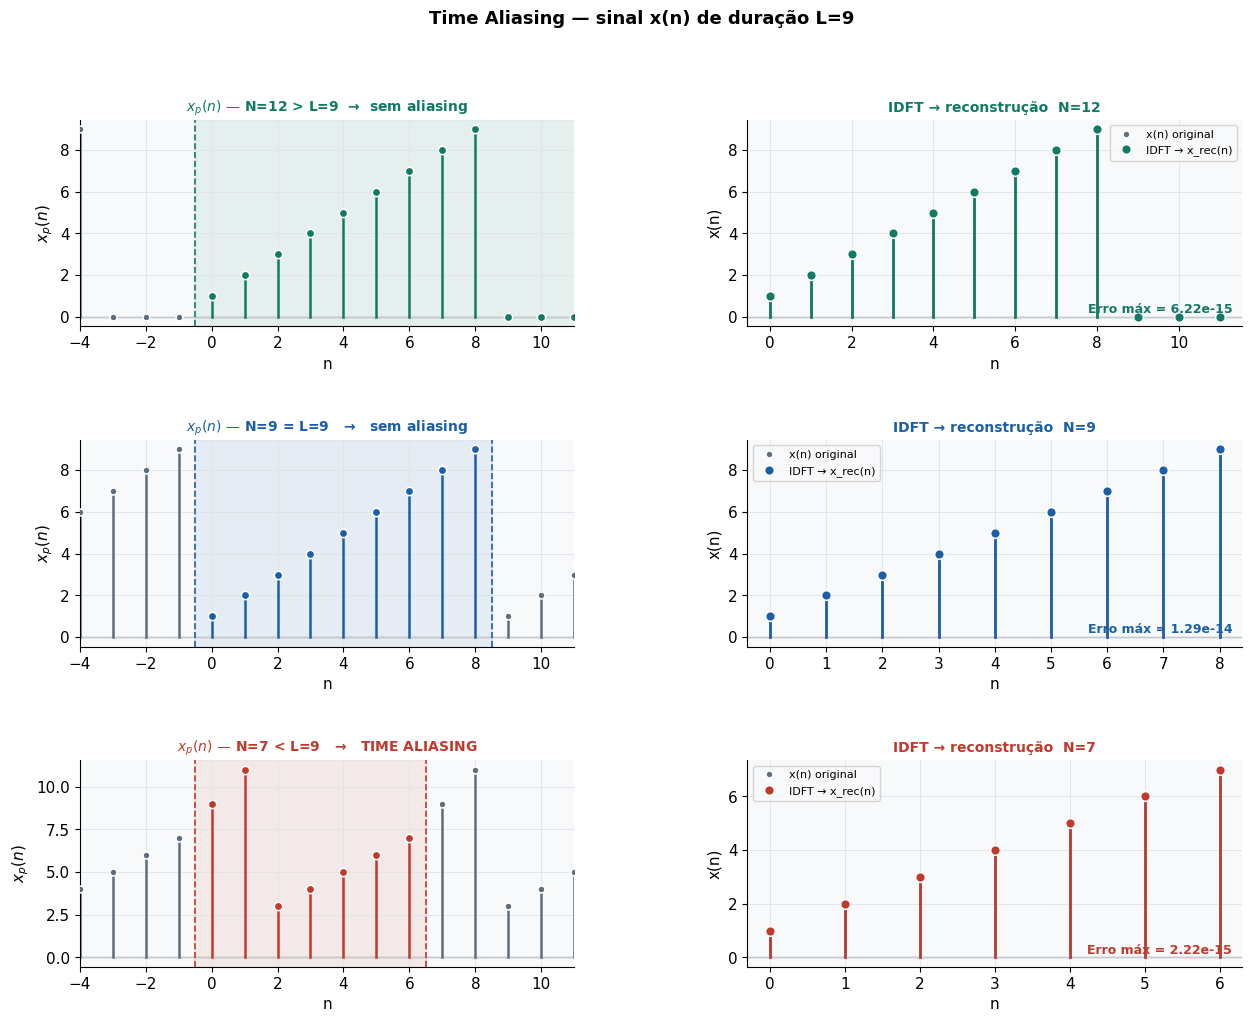

In [14]:
# ── Sinal original: x(n) = {1,2,3,4,5,6,7,8,9} (L=9) ────────────
L    = 9
x_orig = np.arange(1, L + 1, dtype=float)   # 1, 2, 3, ..., L

casos = [
    (12, C_DCOM, 'N=12 > L=9  →  sem aliasing'),
    ( 9, C_ORIG, 'N=9 = L=9   →   sem aliasing'),
    ( 7, C_DSEM, 'N=7 < L=9   →   TIME ALIASING'),
]

fig, axes = plt.subplots(3, 2, figsize=(15, 11))
plt.subplots_adjust(hspace=0.55, wspace=0.35)

for row, (N, cor, titulo) in enumerate(casos):
    # Extensão periódica
    ###for i, ni in enumerate(n_per):
      ## x_per[i] = x_orig[ni_mod] if ni_mod < L else 0.0

    x_per = np.zeros(len(n_per))
    for i, ni in enumerate(n_per):
        for ell in range(-3, 4):
            idx = ni - ell * N
            if 0 <= idx < L:
                x_per[i] += x_orig[idx]

    # IDFT
    X  = dft_direta(x_orig, N)
    xr = idft_direta(X).real

    # Coluna esquerda: extensão periódica
    ax_l = axes[row, 0]
    mask_ok  = (n_per >= 0) & (n_per < N)
    mask_per = ~mask_ok
    stem_plot(ax_l, n_per[mask_ok],  x_per[mask_ok],  cor,    marksize=6)
    stem_plot(ax_l, n_per[mask_per], x_per[mask_per], C_CINZA, marksize=5)
    ax_l.axvspan(-0.5, N - 0.5, alpha=0.08, color=cor)
    ax_l.axvline(-0.5, color=cor, lw=1.2, ls='--')
    ax_l.axvline(N - 0.5, color=cor, lw=1.2, ls='--')
    ax_l.set_title(f'$x_p(n)$ — {titulo}', color=cor, fontsize=10)
    ax_l.set_xlabel('n'); ax_l.set_ylabel('$x_p(n)$')
    ax_l.set_xlim([n_per[0], n_per[-1]])

    # Coluna direita: reconstrução IDFT
    ax_r = axes[row, 1]
    n_rec = np.arange(N)
    # sinal original (referência)
    x_ref = np.concatenate([x_orig, np.zeros(max(0, N - L))])[:N]
    stem_plot(ax_r, n_rec, x_ref, C_CINZA, label='x(n) original', marksize=5)
    stem_plot(ax_r, n_rec, xr,    cor,     label='IDFT → x_rec(n)', marksize=7)
    ax_r.set_title(f'IDFT → reconstrução  N={N}', color=cor, fontsize=10)
    ax_r.set_xlabel('n'); ax_r.set_ylabel('x(n)')
    ax_r.legend(fontsize=8)

    erro = np.max(np.abs(xr[:min(L, N)] - x_orig[:min(L, N)]))
    ax_r.text(0.98, 0.05, f'Erro máx = {erro:.2e}',
              ha='right', va='bottom', transform=ax_r.transAxes,
              color=cor, fontweight='bold', fontsize=9)

plt.suptitle(f'Time Aliasing — sinal x(n) de duração L={L}',
             fontsize=13, fontweight='bold')
plt.show()

### Etapa 2 — Calculando o time aliasing manualmente

In [7]:
# Exemplo numérico: x(n) = {1,2,3,4,5,6,7,8,9}, L=9, N=7
L = 9
N = 7
x_orig = np.arange(1, L + 1, dtype=float)

print(f'x(n) original (L={L}): {x_orig}')
print(f'N = {N}  →  N < L  →  TIME ALIASING')
print()

# Calcular xp[n] = x(n) + x[n-N] + x[n-2N] + ... para 0 ≤ n ≤ N-1
xp = np.zeros(N)
print('Cálculo de xp[n] = x(n) + x[n+N] + ... para 0 ≤ n ≤ N-1:')
print(f'{"n":>3} | {"x(n)":>6} | {"x(n+N)":>8} | {"xp(n)":>8}')
print('-' * 35)
for n_i in range(N):
    contrib = []
    for shift in range(0, L, N):   # contribuições das repetições
        idx = n_i + shift
        if idx < L:
            xp[n_i] += x_orig[idx]
            contrib.append(f'x[{idx}]={x_orig[idx]:.0f}')
    extras = ' + '.join(contrib[1:]) if len(contrib) > 1 else '0'
    print(f'{n_i:>3} | {contrib[0]:>8} + {extras:>8} = {xp[n_i]:>6.0f}')

print()
print(f'xp[n] (0 ≤ n ≤ N-1): {xp}')
print()

# Confirmar com IDFT
X   = dft_direta(x_orig, N)
xr  = idft_direta(X).real
print(f'IDFT produz:          {np.round(xr, 4)}')
print(f'Erro vs xp manual:    {np.max(np.abs(xr - xp)):.2e}')

x(n) original (L=9): [1. 2. 3. 4. 5. 6. 7. 8. 9.]
N = 7  →  N < L  →  TIME ALIASING

Cálculo de xp[n] = x(n) + x[n+N] + ... para 0 ≤ n ≤ N-1:
  n |   x(n) |   x(n+N) |    xp(n)
-----------------------------------
  0 |   x[0]=1 +   x[7]=8 =      9
  1 |   x[1]=2 +   x[8]=9 =     11
  2 |   x[2]=3 +        0 =      3
  3 |   x[3]=4 +        0 =      4
  4 |   x[4]=5 +        0 =      5
  5 |   x[5]=6 +        0 =      6
  6 |   x[6]=7 +        0 =      7

xp[n] (0 ≤ n ≤ N-1): [ 9. 11.  3.  4.  5.  6.  7.]

IDFT produz:          [1. 2. 3. 4. 5. 6. 7.]
Erro vs xp manual:    9.00e+00


### 💡 O que observar

<div style="background-color: #FDEDEC; border-left: 4px solid #A32D2D; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #A32D2D;">Time aliasing é irreversível</strong><br>
Para N=7 e L=9, o sinal reconstruído pela IDFT é $x_p(n)$, não $x(n)$.
Por exemplo, $x_p(0) = x(0) + x(7) = 1 + 8 = 9$, mas $x(0) = 1$.
Não há como separar as contribuições — a informação foi irrecuperavelmente misturada.
Analogia direta ao aliasing espectral na amostragem (abaixo de Nyquist).
</div>

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">Para evitar time aliasing</strong><br>
Duas condições devem ser satisfeitas:<br>
* 1) O sinal deve ter duração <strong>finita</strong> $L$.<br>
* 2) O número de amostras DFT deve ser $N \geq L$.<br>
Quando $N > L$, os zeros inseridos (zero-padding) não distorcem a DFT, estudamos isso na Seção 6.
</div>

---

## <span style="color: #1A5FA8;">6. Zero-Padding — Inserção de Zeros e Efeito Espectral</span>

### Definição

Quando $L < N$, o sinal $x(n)$ de comprimento $L$ é completado com zeros até o comprimento $N$
antes de calcular a DFT de $N$ pontos:

$$x_{zp}(n) = \begin{cases} x(n) & 0 \leq n \leq L-1 \\ 0 & L \leq n \leq N-1 \end{cases}$$

### O que o zero-padding faz ao espectro

Como os zeros não alteram o sinal, a TFTD de $x_{zp}(n)$ é **idêntica** à de $x(n)$:

$$X_{zp}(e^{j\omega}) = X(e^{j\omega})$$

O que muda é apenas o **número de amostras** dessa TFTD:
- Com $N$ maior, a DFT amostra a mesma curva em **mais pontos** → espectro mais denso.
- Isso equivale a **interpolar** o espectro, não a aumentar a resolução espectral real.

<div style="background-color: #FEF9E7; border-left: 4px solid #E67E22; padding: 12px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #E67E22;">Efeito prático do zero-padding:</strong>
A DFT de $N$ pontos com zero-padding fornece mais amostras da mesma TFTD.
O espectro fica mais suave e o pico aparece mais perto de sua frequência real.
Mas a <em>resolução espectral física</em> continua sendo determinada pelo comprimento original $L$.
</div>

###  Simulador interativo de zero-padding

In [8]:
L_sim = 5
x_sim = np.ones(L_sim)

# TFTD contínua
omega_ref = np.linspace(0, 2 * np.pi, 1024, endpoint=False)
X_ref     = np.array([np.sum(x_sim * np.exp(-1j * w * np.arange(L_sim))) for w in omega_ref])

slider_zp = widgets.IntSlider(
    value=L_sim, min=L_sim, max=80, step=1,
    description='N pontos:',
    continuous_update=False,
    layout=widgets.Layout(width='500px')
)
saida_zp = widgets.Output()

def atualizar_zp(change):
    N = change['new']
    x_zp  = np.concatenate([x_sim, np.zeros(N - L_sim)])
    X_zp  = np.fft.fft(x_zp)
    k     = np.arange(N)
    omega_k = 2 * np.pi * k / N

    with saida_zp:
        saida_zp.clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Sinal
        n_all = np.arange(N)
        stem_plot(axes[0], n_all[:L_sim], x_zp[:L_sim], C_ORIG, label='x(n)', marksize=7)
        if N > L_sim:
            stem_plot(axes[0], n_all[L_sim:], x_zp[L_sim:], C_ZEROS, label='zeros', marksize=5)
        axes[0].set_title(f'Sinal com zero-padding — L={L_sim}, N={N}')
        axes[0].set_xlabel('n'); axes[0].set_ylabel('x(n)')
        axes[0].legend(fontsize=9)
        axes[0].set_ylim([-0.3, 1.6])

        # Espectro
        axes[1].plot(omega_ref / np.pi, np.abs(X_ref),
                     color=C_ORIG, lw=1.8, alpha=0.4, label='TFTD (referência)')
        stem_plot(axes[1], omega_k / np.pi, np.abs(X_zp), C_DFT,
                  label=f'DFT N={N}', marksize=5)
        axes[1].set_title(f'|X(k)| — {N} amostras da TFTD  |  Δω = 2π/{N}')
        axes[1].set_xlabel('ω/π'); axes[1].set_ylabel('|X(k)|')
        axes[1].legend(fontsize=9)
        axes[1].set_xlim([0, 2])

        plt.tight_layout()
        plt.show()
        print(f'Zeros inseridos: {N - L_sim}  |  Bins: {N}  |  Δω = 2π/{N} = {2*np.pi/N:.4f}')

slider_zp.observe(atualizar_zp, names='value')
display(slider_zp, saida_zp)
atualizar_zp({'new': L_sim})

IntSlider(value=5, continuous_update=False, description='N pontos:', layout=Layout(width='500px'), max=80, min…

Output()

---

## <span style="color: #1A5FA8;">7. Série, Transformada e DFT — Panorama Unificado</span>

As três ferramentas de análise espectral de sinais de tempo discreto se relacionam assim:

| | Sinal $x(n)$ | Espectro $X$ | Domínio frequência |
|:---:|:---:|:---:|:---:|
| **SFTD** | Periódico, infinito | $a_k$ — discreto, periódico | $\omega_k = 2\pi k/N$ |
| **TFTD** | Aperiódico, possivelmente infinito | $X(e^{j\omega})$ — contínuo, periódico | $\omega \in [-\pi, \pi]$ |
| **DFT** | Finito, comprimento $L$ | $X(k)$ — discreto, $N$ pontos | $\omega_k = 2\pi k/N$, $k=0,\ldots,N-1$ |

### Etapa 1 — Visualização comparativa das três transformadas

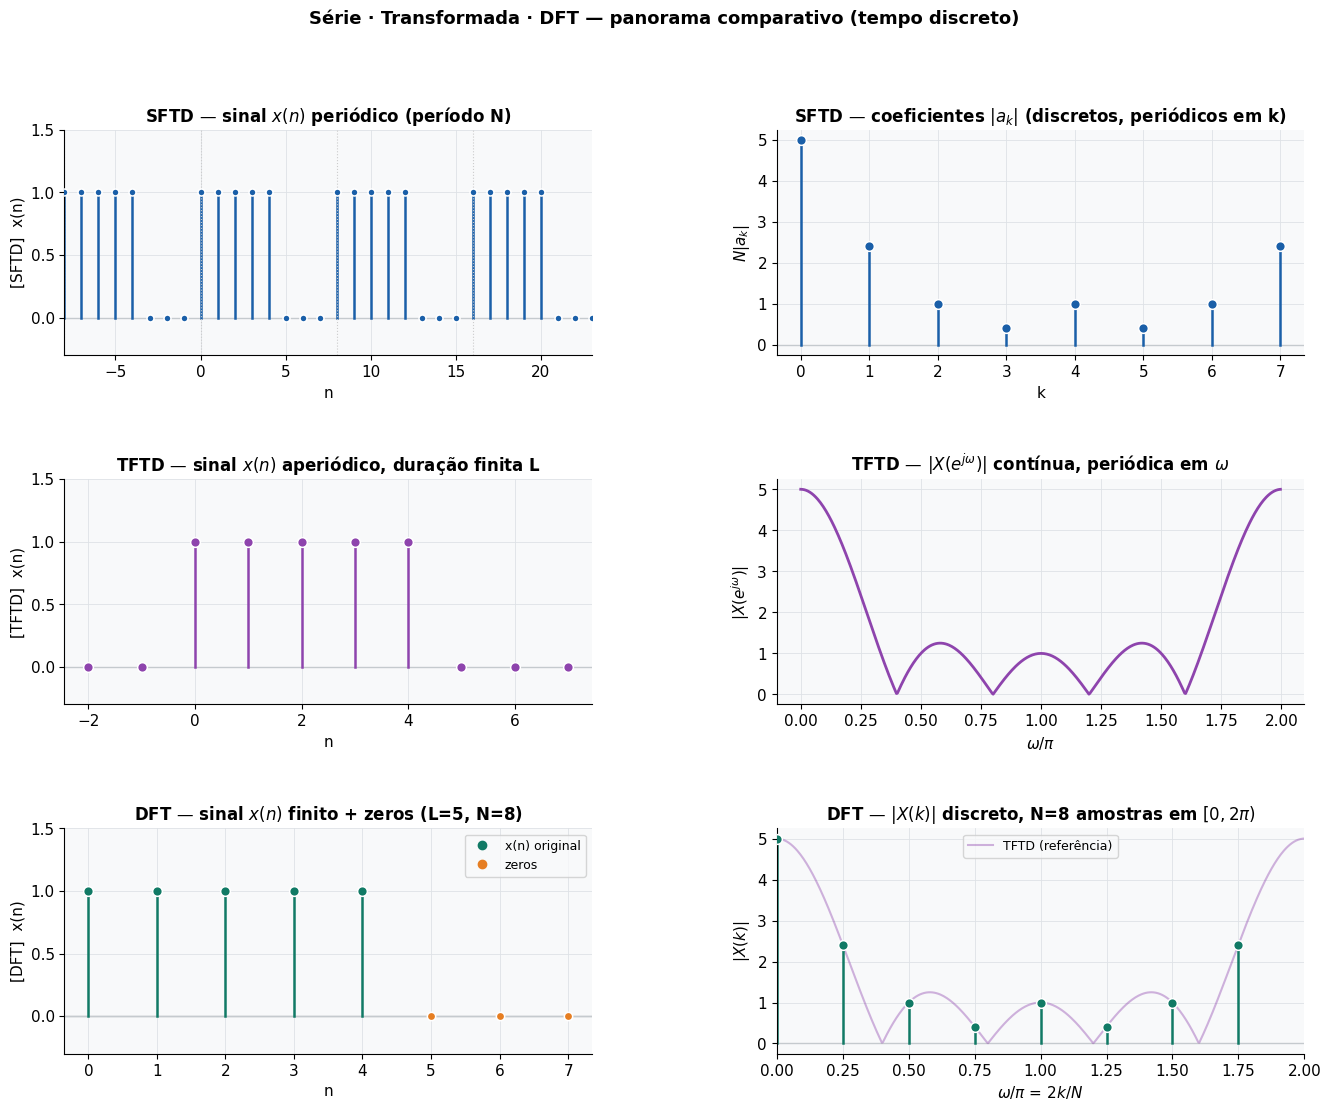

Conexão fundamental:
  SFTD: x(n) periódico → a_k discreto
  TFTD: x(n) aperiódico finito → X(e^jω) contínuo
  DFT:  x(n) finito + N amostras → X(k) discreto = amostras da TFTD


In [10]:
# ── Parâmetros comuns ─────────────────────────────────────────────
N_base = 8    # período da SFTD / pontos da DFT
L      = 5    # duração do pulso para TFTD e DFT

# ── SFTD: sinal periódico ─────────────────────────────────────────
n_per   = np.arange(-N_base, 3 * N_base)
x_sftd  = np.array([1.0 if (ni % N_base) < L else 0.0 for ni in n_per])
k_sftd  = np.arange(N_base)
a_k     = np.fft.fft(x_sftd[:N_base]) / N_base

# ── TFTD: sinal finito, espectro contínuo ─────────────────────────
x_tftd  = np.ones(L)
omega_c = np.linspace(0, 2 * np.pi, 512, endpoint=False)
X_tftd  = np.array([np.sum(x_tftd * np.exp(-1j * w * np.arange(L))) for w in omega_c])

# ── DFT: sinal finito, espectro discreto ─────────────────────────
x_dft   = np.ones(L)
X_dft   = np.fft.fft(x_dft, n=N_base)
k_dft   = np.arange(N_base)

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

# ── Linha 1: SFTD ─────────────────────────────────────────────────
ax00 = fig.add_subplot(gs[0, 0])
stem_plot(ax00, n_per, x_sftd, C_ORIG, marksize=5)
ax00.set_title('SFTD — sinal $x(n)$ periódico (período N)')
ax00.set_xlabel('n'); ax00.set_ylabel('x(n)')
ax00.set_xlim([n_per[0], n_per[-1]])
ax00.set_ylim([-0.3, 1.5])
for p in range(-1, 3):
    ax00.axvline(p * N_base, color='#ccc', lw=0.8, ls=':')

ax01 = fig.add_subplot(gs[0, 1])
stem_plot(ax01, k_sftd, np.abs(a_k) * N_base, C_ORIG, marksize=7)
ax01.set_title('SFTD — coeficientes $|a_k|$ (discretos, periódicos em k)')
ax01.set_xlabel('k'); ax01.set_ylabel('$N|a_k|$')

# ── Linha 2: TFTD ─────────────────────────────────────────────────
ax10 = fig.add_subplot(gs[1, 0])
n_tftd_ext = np.arange(-2, L + 3)
x_tftd_ext = np.array([1.0 if 0 <= ni < L else 0.0 for ni in n_tftd_ext])
stem_plot(ax10, n_tftd_ext, x_tftd_ext, C_DFT, marksize=7)
ax10.set_title('TFTD — sinal $x(n)$ aperiódico, duração finita L')
ax10.set_xlabel('n'); ax10.set_ylabel('x(n)')
ax10.set_ylim([-0.3, 1.5])

ax11 = fig.add_subplot(gs[1, 1])
ax11.plot(omega_c / np.pi, np.abs(X_tftd), color=C_DFT, lw=2.0)
ax11.set_title('TFTD — $|X(e^{j\\omega})|$ contínua, periódica em $\\omega$')
ax11.set_xlabel('$\\omega/\\pi$'); ax11.set_ylabel('$|X(e^{j\\omega})|$')

# ── Linha 3: DFT ──────────────────────────────────────────────────
ax20 = fig.add_subplot(gs[2, 0])
n_dft_ext = np.arange(-1, N_base + 2)
x_dft_ext = np.array([1.0 if 0 <= ni < L else (0.0 if ni < N_base else 0.0) for ni in n_dft_ext])
stem_plot(ax20, np.arange(L),         np.ones(L),         C_DCOM, marksize=7)
stem_plot(ax20, np.arange(L, N_base), np.zeros(N_base-L), C_ZEROS, marksize=6)
ax20.set_title(f'DFT — sinal $x(n)$ finito + zeros (L={L}, N={N_base})')
ax20.set_xlabel('n'); ax20.set_ylabel('x(n)')
ax20.set_ylim([-0.3, 1.5])
ax20.plot([], [], color=C_DCOM,  marker='o', lw=0, label='x(n) original')
ax20.plot([], [], color=C_ZEROS, marker='o', lw=0, label='zeros')
ax20.legend(fontsize=9)

ax21 = fig.add_subplot(gs[2, 1])
ax21.plot(omega_c / np.pi, np.abs(X_tftd), color=C_DFT, lw=1.5, alpha=0.4, label='TFTD (referência)')
stem_plot(ax21, 2 * k_dft / N_base, np.abs(X_dft), C_DCOM, marksize=7)
ax21.set_title(f'DFT — $|X(k)|$ discreto, N={N_base} amostras em $[0, 2\\pi)$')
ax21.set_xlabel('$\\omega/\\pi$ = $2k/N$'); ax21.set_ylabel('$|X(k)|$')
ax21.set_xlim([0, 2])
ax21.legend(fontsize=9)

# Rótulos das linhas
for ax, lbl in [(ax00, 'SFTD'), (ax10, 'TFTD'), (ax20, 'DFT')]:
    ax.set_ylabel(f'[{lbl}]  {ax.get_ylabel()}')

plt.suptitle('Série · Transformada · DFT — panorama comparativo (tempo discreto)',
             fontsize=13, fontweight='bold')
plt.show()

print('Conexão fundamental:')
print('  SFTD: x(n) periódico → a_k discreto')
print('  TFTD: x(n) aperiódico finito → X(e^jω) contínuo')
print('  DFT:  x(n) finito + N amostras → X(k) discreto = amostras da TFTD')

### 💡 O que observar

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">A DFT une as três ferramentas</strong><br>
Os coeficientes $a_k$ da SFTD e os bins $X(k)$ da DFT são essencialmente a mesma coisa:
amostras do espectro contínuo $X(e^{j\omega})$ nos pontos $\omega_k = 2\pi k/N$.
A diferença é que a SFTD exige que $x(n)$ seja periódico, enquanto a DFT funciona
com qualquer sinal de duração finita.
</div>



---

## <span style="color: #1A5FA8;">10. Questões para Reflexão</span>

### Sobre TFTD e Amostragem em Frequência

1. A TFTD $X(e^{j\omega})$ é periódica em $\omega$. Por que é suficiente amostrá-la apenas
   no intervalo $[0, 2\pi)$ para representá-la completamente?

2. Um sinal $x(n)$ tem comprimento $L = 10$. Você quer calcular sua DFT com $N = 16$ pontos.
   Quantos zeros são inseridos? Qual é o espaçamento $\Delta\omega$ entre bins?
   Se $F_s = 8000$ Hz, qual é a frequência do bin $k = 3$ em Hz?

3. Por que é suficiente amostrar a TFTD em apenas **um** período de $2\pi$,
   e não em dois ou mais períodos?

### Sobre DFT e IDFT

4. Calcule manualmente $X[0]$, $X[1]$, $X[2]$ e $X[3]$ para o sinal $x(n) = \{1, 0, 1, 0\}$ com $N=4$.
   *(Dica: $W_4 = e^{-j\pi/2} = -j$)*.

5. Um sinal real $x(n)$ tem DFT $X(k)$. Mostre que $X[N-k] = X^*[k]$
   (simetria conjugada). Qual é a consequência para o armazenamento computacional?

6. Se $X(k) = 1$ para todo $k = 0, 1, \ldots, N-1$, qual é o sinal $x(n)$ correspondente?
   *(Aplique a IDFT diretamente).*

### Sobre Time Aliasing

7. Um sinal $x(n) = \{3, 1, 4, 1, 5, 9, 2, 6\}$ tem $L = 8$.
   Você calcula a DFT com $N = 6$ pontos. Calcule $x_p[0]$ e $x_p[1]$ da extensão periódica.
   O sinal pode ser recuperado? Justifique.

8. O time aliasing é análogo ao aliasing espectral (violação de Nyquist).
   Complete a analogia: na amostragem temporal, amostrar abaixo de Nyquist causa sobreposição
   de réplicas no domínio da **frequência**. Na DFT, usar $N < L$ causa sobreposição
   de réplicas no domínio do ___?___. Explique com as extensões periódicas.

### Sobre Zero-Padding

9. Um colega afirma: *"Usando zero-padding com N=100 sobre um sinal de L=10 amostras,
   consigo uma resolução espectral 10 vezes melhor"*. Ele está correto?
   Explique a diferença entre resolução espectral real e interpolação espectral.

10. Dado o sinal $x(n) = \delta[n] - \delta[n-1]$ com $L = 2$, calcule analiticamente
    $X(e^{j\omega})$ (TFTD) e depois $X(k)$ (DFT) para $N = 4$.
    Verifique que os bins DFT são amostras da TFTD nos pontos $\omega_k = 2\pi k/4$.

---

## <span style="color: #1A5FA8;">Referências</span>

- **Oppenheim & Schafer** — *Processamento em Tempo Discreto de Sinais*, 3ª ed. Pearson, 2013. *(Cap. 8 — A Transformada Discreta de Fourier)*
- **Proakis & Manolakis** — *Digital Signal Processing*, 4ª ed. Pearson, 2007. *(Cap. 6 — The Discrete Fourier Transform)*
- **Oppenheim, Schafer & Buck** — *Discrete-Time Signal Processing*, 2ª ed. Prentice Hall, 1999.
- **Smith, J.O.** — *Mathematics of the DFT*, Stanford CCRMA. Disponível em: https://ccrma.stanford.edu/~jos/mdft/
- **NumPy Documentation** — *numpy.fft*. Disponível em: https://numpy.org/doc/stable/reference/routines.fft.html

---

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 20px;">
Laboratório de PDS — UFCG / DEE &nbsp;|&nbsp; Profa. Luciana Ribeiro Veloso
</div>